In [1]:
import pandas as pd
data = pd.read_csv('results/summary_stats.csv')
data.head()

,model,precision,dataset,accuracy,pass@k,confidence,failure_rate,diversity,cutoff_rate,tps,total_time,total_time_sec,avg_latency_sec,n_questions
0,Qwen/Qwen3.5-0.8B,16bit,gsm8k,0.650493,0.811979,0.583397,0.000000,3.942381,0.160633,252.354467,5h 56m 55s,21414.79,16.24,1319
1,Qwen/Qwen3.5-0.8B,8bit,gsm8k,0.636846,0.830174,0.563590,0.000000,4.089462,0.149924,273.507411,5h 30m 8s,19807.71,15.02,1319
2,Qwen/Qwen3.5-0.8B,8bit,cqa,0.577396,0.864865,0.712969,0.000205,2.435708,0.002252,275.604285,2h 35m 51s,9350.89,7.66,1221
3,Qwen/Qwen3.5-0.8B,4bit,gsm8k,0.551175,0.737680,0.510330,0.000000,4.501895,0.171531,262.229723,5h 43m 31s,20611.37,15.63,1319
4,Qwen/Qwen3.5-0.8B,4bit,cqa,0.566749,0.866503,0.678484,0.001331,2.647830,0.000410,218.628957,1h 34m 8s,5647.63,4.63,1221


In [2]:
# columns i want to display model, precision, dataset, accuracy, confidence, pass@k, diversity tps and total time n_questions
columns_to_display = ['model', 'precision', 'dataset', 'accuracy', 'confidence', 'pass@k', 'diversity', 'tps', 'total_time', 'n_questions']
df_filtered = data[columns_to_display].copy()
numeric_cols = df_filtered.select_dtypes(include=['float64', 'int64']).columns
df_filtered[numeric_cols] = df_filtered[numeric_cols].round(3)
df_sorted = df_filtered.sort_values(by=['dataset', 'accuracy'])
df_filtered

,model,precision,dataset,accuracy,confidence,pass@k,diversity,tps,total_time,n_questions
0,Qwen/Qwen3.5-0.8B,16bit,gsm8k,0.650,0.583,0.812,3.942,252.354,5h 56m 55s,1319
1,Qwen/Qwen3.5-0.8B,8bit,gsm8k,0.637,0.564,0.830,4.089,273.507,5h 30m 8s,1319
2,Qwen/Qwen3.5-0.8B,8bit,cqa,0.577,0.713,0.865,2.436,275.604,2h 35m 51s,1221
3,Qwen/Qwen3.5-0.8B,4bit,gsm8k,0.551,0.510,0.738,4.502,262.230,5h 43m 31s,1319
4,Qwen/Qwen3.5-0.8B,4bit,cqa,0.567,0.678,0.867,2.648,218.629,1h 34m 8s,1221


In [5]:
import pandas as pd

# Read the data
data = pd.read_csv('results/summary_stats.csv')

# Define the columns you want to display
columns_to_display = [
    'model', 
    'precision', 
    'dataset', 
    'accuracy', 
    'confidence', 
    'pass@k', 
    'diversity', 
    'tps', 
    'total_time', 
    'n_questions'
]

# Filter the dataframe to keep only the desired columns
df_filtered = data[columns_to_display].copy()

# Identify numeric columns to round
numeric_cols = df_filtered.select_dtypes(include=['float64', 'int64']).columns

# Round the numeric columns to 3 decimal places
df_filtered[numeric_cols] = df_filtered[numeric_cols].round(3)

# Sort by 'dataset', then by 'accuracy' (default is ascending order)
df_sorted = df_filtered.sort_values(by=['dataset', 'accuracy'],ascending=False)

# Display the result
df_sorted

# If you want to save this sorted view to a new CSV:
# df_sorted.to_csv('results/sorted_summary_stats.csv', index=False)

,model,precision,dataset,accuracy,confidence,pass@k,diversity,tps,total_time,n_questions
0,Qwen/Qwen3.5-0.8B,16bit,gsm8k,0.650,0.583,0.812,3.942,252.354,5h 56m 55s,1319
1,Qwen/Qwen3.5-0.8B,8bit,gsm8k,0.637,0.564,0.830,4.089,273.507,5h 30m 8s,1319
3,Qwen/Qwen3.5-0.8B,4bit,gsm8k,0.551,0.510,0.738,4.502,262.230,5h 43m 31s,1319
2,Qwen/Qwen3.5-0.8B,8bit,cqa,0.577,0.713,0.865,2.436,275.604,2h 35m 51s,1221
4,Qwen/Qwen3.5-0.8B,4bit,cqa,0.567,0.678,0.867,2.648,218.629,1h 34m 8s,1221


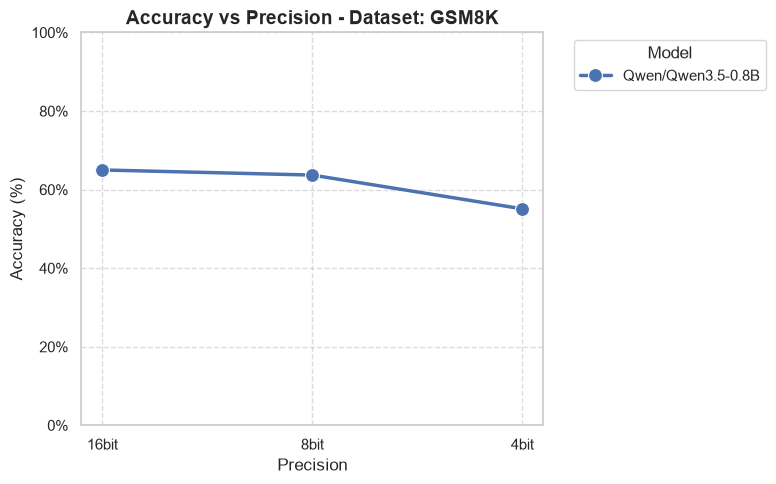

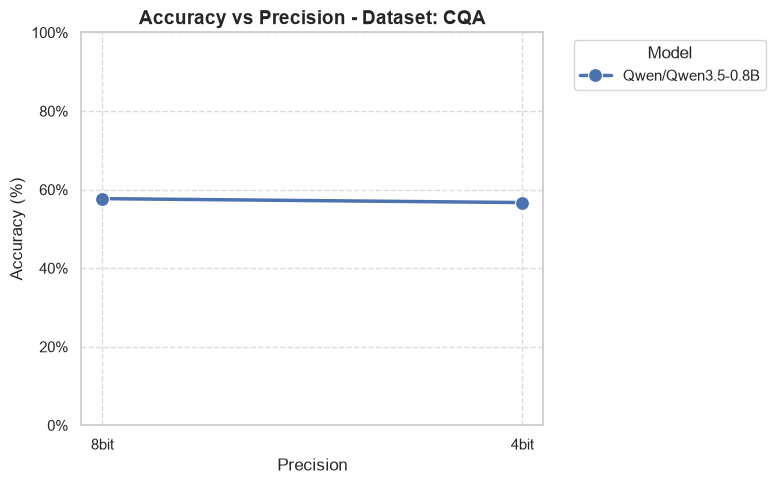

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# 1. Read and prepare the data
data = pd.read_csv('results/summary_stats.csv')

columns_to_display = [
    'model', 'precision', 'dataset', 'accuracy', 'confidence', 
    'pass@k', 'diversity', 'tps', 'total_time', 'n_questions'
]
df_filtered = data[columns_to_display].copy()

numeric_cols = df_filtered.select_dtypes(include=['float64', 'int64']).columns
df_filtered[numeric_cols] = df_filtered[numeric_cols].round(3)

# 2. Get a list of unique datasets
datasets = df_filtered['dataset'].unique()

# Set a nice visual style
sns.set_theme(style="whitegrid")

# 3. Loop through each dataset and create an individual line plot
for dataset_name in datasets:
    # Filter data for the current dataset
    df_subset = df_filtered[df_filtered['dataset'] == dataset_name].copy()
    
    # Sort precision logically (16bit -> 8bit -> 4bit) for the line flow
    precision_order = ['16bit', '8bit', '4bit']
    df_subset['precision'] = pd.Categorical(df_subset['precision'], categories=precision_order, ordered=True)
    df_subset = df_subset.sort_values('precision')
    
    # Create a new figure for each dataset
    plt.figure(figsize=(8, 5))
    
    # Create the line plot
    sns.lineplot(
        data=df_subset, 
        x='precision', 
        y='accuracy', 
        hue='model', 
        marker='o', 
        linewidth=2.5,
        markersize=10
    )
    
    # --- Y-AXIS CONFIGURATION ---
    # Force the Y-axis to go from 0 to 1.0 (0% to 100%)
    plt.ylim(0, 1.0)
    
    # Format the Y-axis to display as percentages (0%, 20%, 40%...)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    # ----------------------------
    
    # Add titles and labels
    plt.title(f'Accuracy vs Precision - Dataset: {dataset_name.upper()}', fontsize=14, fontweight='bold')
    plt.xlabel('Precision', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    
    # Add a subtle grid for readability
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Place the legend outside the plot
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()

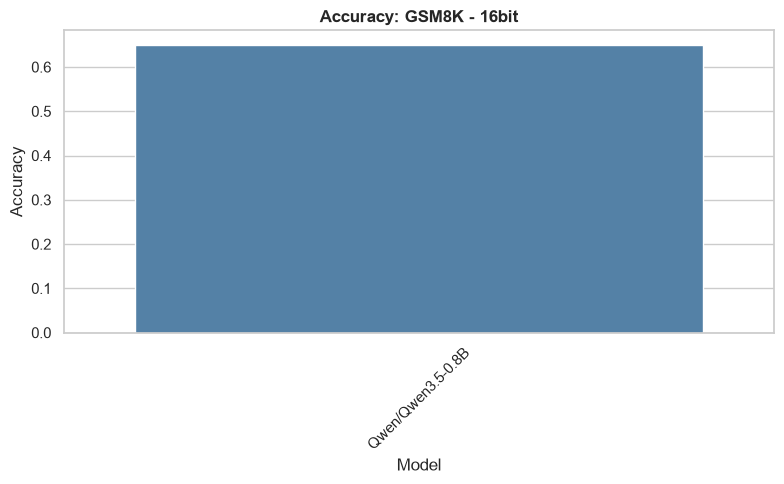

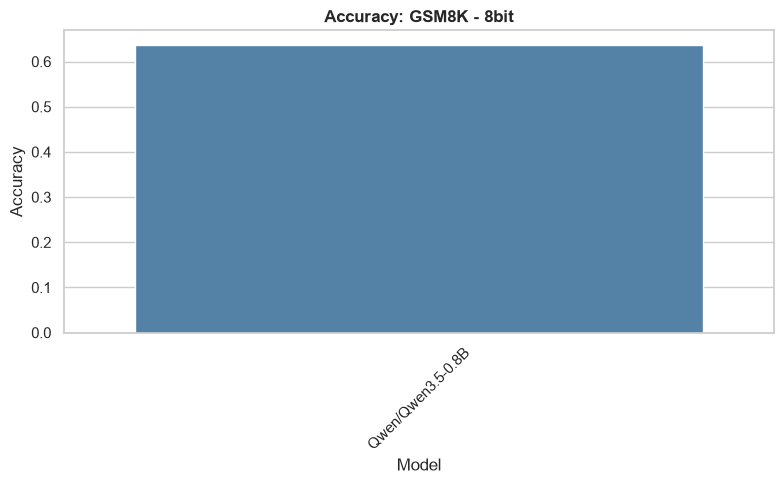

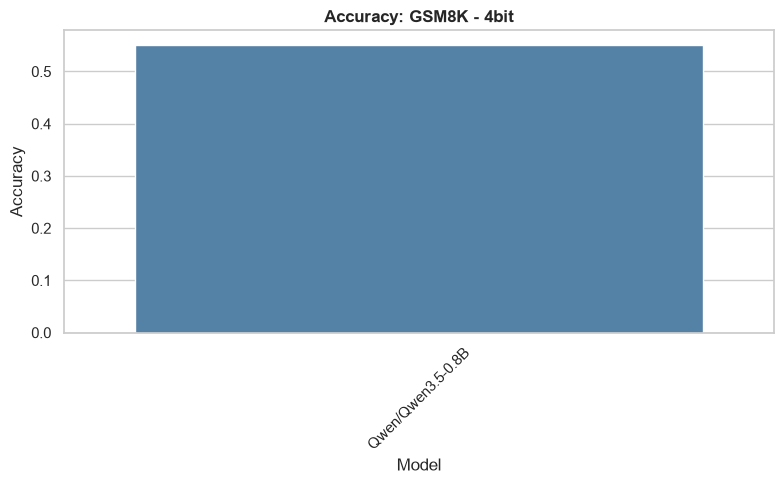

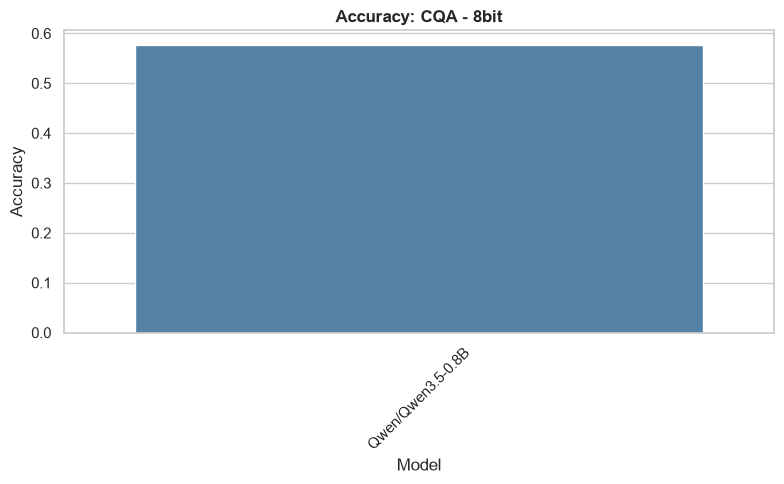

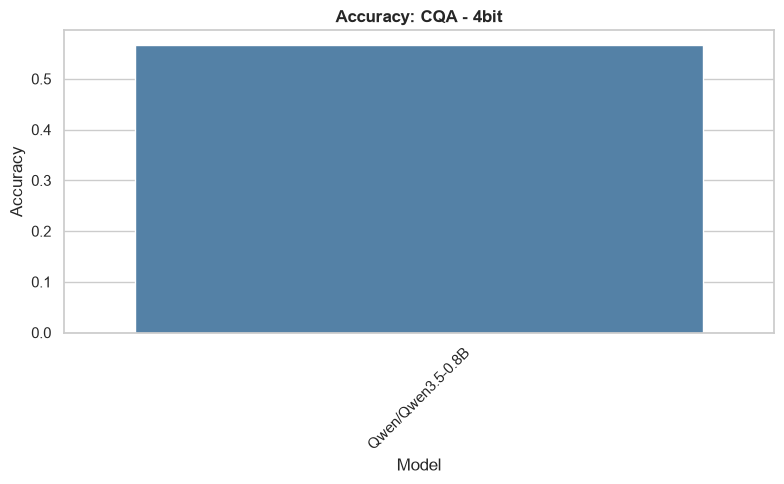

In [7]:
for dataset_name in datasets:
    df_dataset = df_filtered[df_filtered['dataset'] == dataset_name]
    precisions = df_dataset['precision'].unique()
    
    for precision in precisions:
        df_subset = df_dataset[df_dataset['precision'] == precision]
        
        plt.figure(figsize=(8, 5))
        sns.barplot(data=df_subset, x='model', y='accuracy', color='steelblue')
        
        plt.title(f'Accuracy: {dataset_name.upper()} - {precision}', fontweight='bold')
        plt.xlabel('Model')
        plt.ylabel('Accuracy')
        plt.xticks(rotation=45) # Rotate model names if they are long
        plt.tight_layout()
        plt.show()